In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sb

In [2]:
df = pd.read_csv(
    r"C:\Users\admin\Downloads\website_Data_set\website_traffic_analysis.csv"
)

In [3]:
df

,Date,Channel Group,Landing Page,Sessions,Users,Bounce Rate,Avg Session Duration,Pages per Session,Goal Completions,Conversion Rate
0,2025-01-01,Organic Search,/home,1200,950,42.5,180,3.8,65,5.42
1,2025-01-01,Paid Search,/pricing,850,700,55.2,145,2.9,48,5.65
2,2025-01-01,Referral,/blog-seo,620,510,38.7,210,4.5,31,5.00
3,2025-01-01,Direct,/home,980,760,35.4,225,5.2,72,7.35
4,2025-01-02,Organic Search,/products,1300,1020,40.8,190,4.1,70,5.38
5,2025-01-02,Paid Search,/pricing,900,740,58.1,135,2.7,45,5.00
6,2025-01-02,Referral,/blog-ai,650,530,36.5,215,4.8,35,5.38
7,2025-01-02,Direct,/contact,750,610,30.2,240,5.5,60,8.00
8,2025-01-03,Organic Search,/home,1450,1150,39.6,205,4.4,82,5.66
9,2025-01-03,Paid Search,/products,920,760,56.8,140,2.8,50,5.43


In [4]:

traffic_sources = (
    df.groupby("Channel Group")["Sessions"]
      .sum()
      .sort_values(ascending=False)
)

print(traffic_sources)

Channel Group
Organic Search    6850
Direct            4710
Paid Search       4620
Referral          3380
Name: Sessions, dtype: int64


In [5]:
source_performance = (
    df.groupby("Channel Group")
      .agg({
          "Sessions":"sum",
          "Users":"sum",
          "Goal Completions":"sum",
          "Conversion Rate":"mean",
          "Bounce Rate":"mean"
      })
      .round(2)
)

print(source_performance)

                Sessions  Users  Goal Completions  Conversion Rate  \
Channel Group                                                        
Direct              4710   3740               376             7.95   
Organic Search      6850   5410               383             5.58   
Paid Search         4620   3800               244             5.29   
Referral            3380   2770               191             5.63   

                Bounce Rate  
Channel Group                
Direct                31.12  
Organic Search        40.60  
Paid Search           56.64  
Referral              36.46  


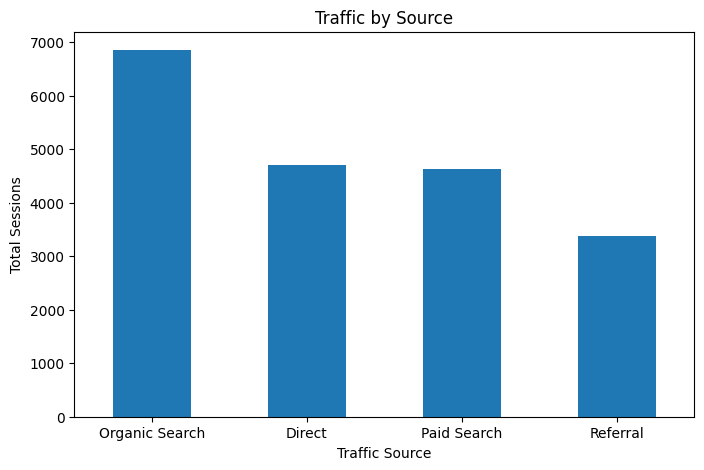

In [7]:
import matplotlib.pyplot as plt

traffic_sources = (
    df.groupby("Channel Group")["Sessions"]
      .sum()
      .sort_values(ascending=False)
)

traffic_sources.plot(kind="bar", figsize=(8,5))

plt.title("Traffic by Source")
plt.xlabel("Traffic Source")
plt.ylabel("Total Sessions")
plt.xticks(rotation=0)
plt.show()

In [9]:


# Average Session Duration
avg_duration = df["Avg Session Duration"].mean()

# Average Pages per Session
avg_pages = df["Pages per Session"].mean()

print("Average Session Duration:", round(avg_duration, 2), "seconds")
print("Average Pages per Session:", round(avg_pages, 2))

Average Session Duration: 199.75 seconds
Average Pages per Session: 4.35


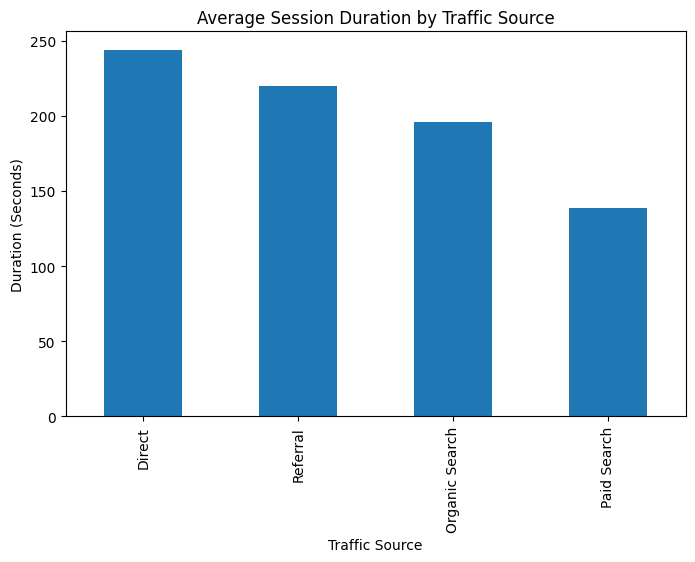

In [10]:


duration = (
    df.groupby("Channel Group")["Avg Session Duration"]
      .mean()
      .sort_values(ascending=False)
)

duration.plot(kind="bar", figsize=(8,5))

plt.title("Average Session Duration by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Duration (Seconds)")
plt.show()

In [11]:


total_goals = df["Goal Completions"].sum()
avg_conversion_rate = df["Conversion Rate"].mean()

print("Total Goal Completions:", total_goals)
print("Average Conversion Rate:", round(avg_conversion_rate, 2), "%")

Total Goal Completions: 1194
Average Conversion Rate: 6.11 %


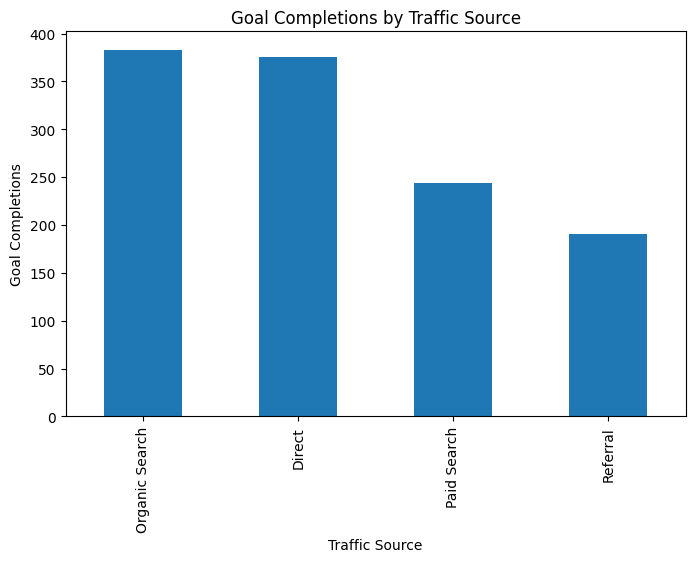

In [12]:


goals = (
    df.groupby("Channel Group")["Goal Completions"]
      .sum()
      .sort_values(ascending=False)
)

goals.plot(kind="bar", figsize=(8,5))

plt.title("Goal Completions by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Goal Completions")
plt.show()

In [14]:

df.to_csv("output3.csv", index=False)